# Practicing Pandas Basics

__Solve the following four exercises - each proper solution is worth 1 point.__

##### Exercise 1: Load the data-set 'dow_jones_index.data' using pandas ('dow_jones_index.names' contains a description of the data).

In [1]:
import pandas as pd
# We haven't gotten "dow_jones_index.data" file, 
# and I suppose "dow_jones_index.csv" was ment
dow_jones_index = pd.read_csv("dow_jones_index.csv")

##### Exercise 2: Validate the numerical columns in the following ways: 

##### (a) list all values of the columns with non-numerical values and their occurrences; 

In [2]:
import numpy as np
# All non-numerical values with theis occurrences (750 in total)
print(dow_jones_index.select_dtypes(exclude=np.number)) 

    stock       date    open    high     low   close next_weeks_open  \
0      AA   1/7/2011  $15.82  $16.72  $15.78  $16.42          $16.71   
1      AA  1/14/2011  $16.71  $16.71  $15.64  $15.97          $16.19   
2      AA  1/21/2011  $16.19  $16.38  $15.60  $15.79          $15.87   
3      AA  1/28/2011  $15.87  $16.63  $15.82  $16.13          $16.18   
4      AA   2/4/2011  $16.18  $17.39  $16.18  $17.14          $17.33   
..    ...        ...     ...     ...     ...     ...             ...   
745   XOM  5/27/2011  $80.22  $82.63  $80.07  $82.63          $83.28   
746   XOM   6/3/2011  $83.28  $83.75  $80.18  $81.18          $80.93   
747   XOM  6/10/2011  $80.93  $81.87  $79.72  $79.78          $80.00   
748   XOM  6/17/2011  $80.00  $80.82  $78.33  $79.02          $78.65   
749   XOM  6/24/2011  $78.65  $81.12  $76.78  $76.78          $76.88   

    next_weeks_close  
0             $15.97  
1             $15.79  
2             $16.13  
3             $17.14  
4             $17.37

##### (b) look at the dispersion of the columns with numerical values (7-number-summary and/or boxplot)

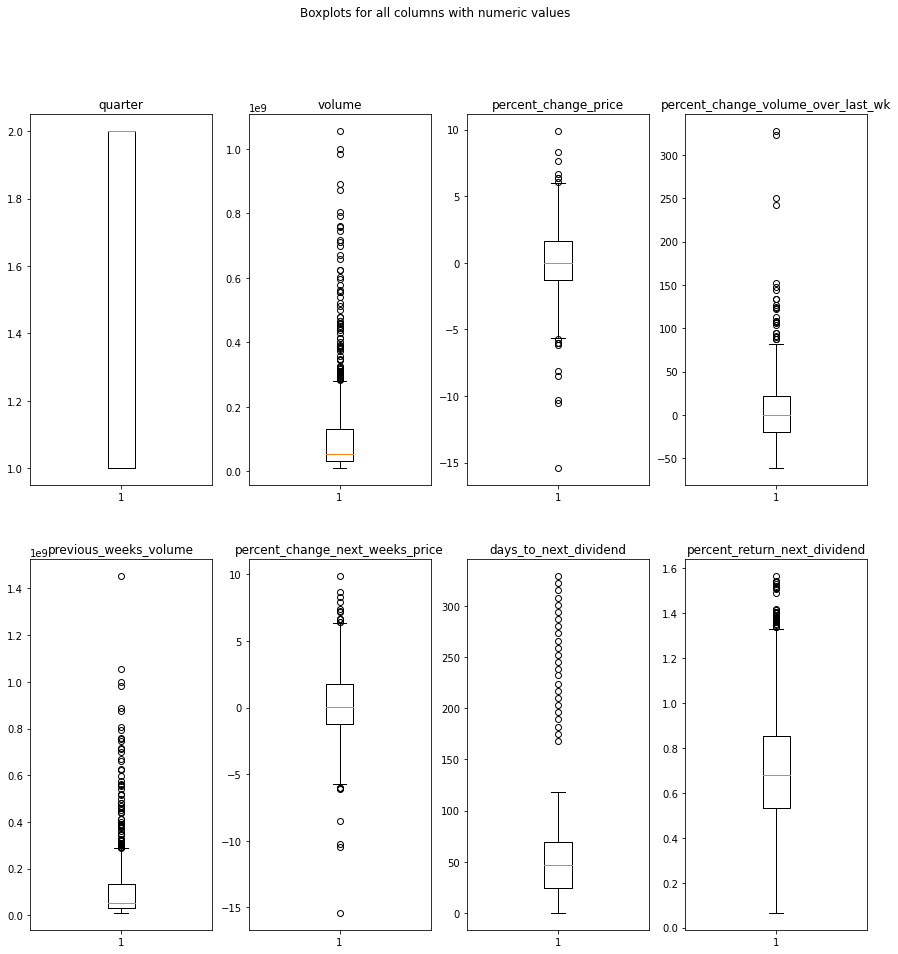

In [3]:
import matplotlib.pyplot as plt

# Make a list of columns which contains non values
columns_with_nan_values = dow_jones_index.columns[
    dow_jones_index.isna().any()
].tolist()

dow_jones_index_no_none = pd.DataFrame()

# Remove all non values, they will influence negatively the boxplot
for i in range(len(columns_with_nan_values)):
    dow_jones_index_no_none = dow_jones_index[
        dow_jones_index[columns_with_nan_values[i]].notna()
    ]

dow_jones_index_numeric = dow_jones_index_no_none.select_dtypes(
    include=np.number
)

all_numeric_columns = list(dow_jones_index_numeric.columns)


fig, axs = plt.subplots(int(len(all_numeric_columns)/4),
                        int(len(all_numeric_columns)/2),
                        figsize=(15, 15))
axs = axs.ravel()
# Plot all the boxplots where columns has numeric values
for i in range(len(all_numeric_columns)):
    axs[i].boxplot(dow_jones_index_numeric[all_numeric_columns[i]])
    axs[i].set_title(all_numeric_columns[i])
fig.suptitle('Boxplots for all columns with numeric values')
plt.show()

##### Exercise 3: Check if all rows are in the proper chronological order and fix the order if necessary. Plot the chart of the closing stock price for the Cisco share. (Remark: Correct the date property using pd.to_datetime()).


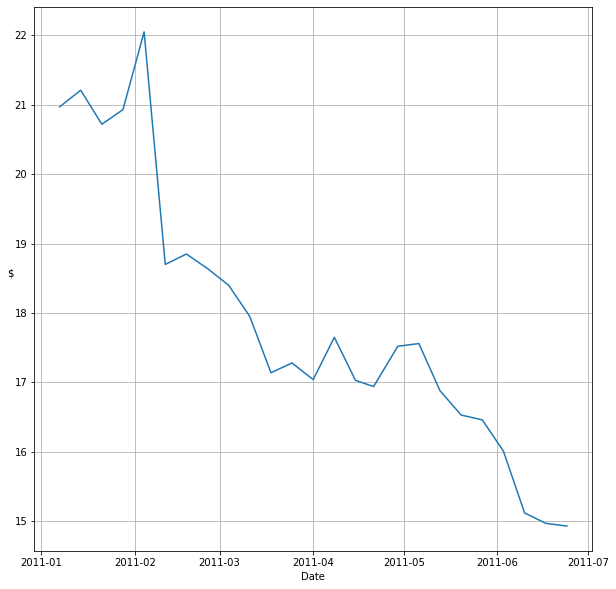

In [4]:
dow_jones_index['date'] = pd.to_datetime(dow_jones_index['date'])
dow_jones_index = dow_jones_index.sort_values('date').reset_index(drop=True)
pd.set_option('mode.chained_assignment', None) 
cisco = dow_jones_index.loc[dow_jones_index['stock'] == "CSCO"]
cisco['close'] = cisco['close'].replace({'\$':''}, regex = True)
cisco['close'] = cisco['close'].astype(float)

plt.rcParams['figure.figsize'] = [10, 10]
plt.grid()
plt.plot(cisco['date'], cisco['close'])
plt.xlabel('Date')
plt.ylabel('$').set_rotation(0)
plt.show()

##### Exercise 4: Add a column with the absolute difference between highest and lowest stock price of this day.

In [5]:
cisco['high'] = cisco['high'].replace({'\$':''}, regex=True)
cisco['high'] = cisco['high'].astype(float)
cisco['low'] = cisco['low'].replace({'\$':''}, regex=True)
cisco['low'] = cisco['low'].astype(float)

cisco['High/Low Difference'] = cisco['high'] - cisco['low']

print(cisco['High/Low Difference'])

9      0.62
33     0.53
76     0.83
115    0.88
133    1.44
156    3.73
180    0.39
228    0.51
264    0.48
284    0.61
318    0.91
341    0.44
379    0.61
397    1.29
444    0.79
451    0.44
508    0.74
517    0.42
555    1.35
579    0.53
612    0.35
638    0.84
665    1.16
691    0.50
745    0.72
Name: High/Low Difference, dtype: float64
